# Task 1: Wind Patterns Project

## Title
Comparative Analysis of Wind Speed and Vertical Velocity Across Three Atmospheric Levels Using DYAMOND GEOS U, V, and W Components

## Goal

This project analyzes DYAMOND GEOS atmospheric data to study how wind behavior changes across atmospheric levels.

The analysis uses:
- the east-west wind component (**U**),
- the north-south wind component (**V**),
- the horizontal wind speed magnitude computed from **U** and **V**, and
- the vertical velocity component (**W**).

The main goal is to compare horizontal wind speed and vertical atmospheric motion across three selected atmospheric levels for a fixed face and timestep. This helps provide a better understanding of how wind structure changes with height and how it may relate to atmospheric processes such as precipitation patterns and storm development.

## Step 1: Import Required Libraries

In this section, the required Python libraries are imported for the analysis.

- **NumPy** is used for numerical operations.
- **OpenVisus** is used to load and access DYAMOND GEOS data.
- **Matplotlib** is used to visualize wind speed and vertical velocity patterns.

In [10]:
import numpy as np
import OpenVisus as ov
import matplotlib.pyplot as plt

## Step 2: Define the Analysis Parameters

This section sets the main parameters for the project.

- **face = 2** selects the cubed-sphere face used for analysis.
- **time = 1** selects the timestep.
- **levels** defines the three atmospheric levels compared in this project:
  1. lower level: [5, 6]
  2. middle level: [25, 26]
  3. upper level: [50, 51]
- **y\_slice = [1000, 1001]** defines the vertical cross-section used later in the analysis.

These parameters allow the project to compare both horizontal wind speed patterns and vertical structure.

In [11]:
# Select the cubed-sphere face and timestep for analysis
face = 2
time = 1

# Define three atmospheric levels for comparison:
# lower level, middle level, and upper level
levels = [[5, 6], [25, 26], [50, 51]]

# Select one y-location for the vertical slice analysis
# This will be used later to study how wind changes with height
y_slice = [1000, 1001]

## Step 3: Load the U and V Wind Datasets

In this section, the dataset locations for the U and V wind components are constructed using the selected face.

- **U** represents east-west wind motion.
- **V** represents north-south wind motion.

Both datasets are loaded using the OpenVisus framework.  
These datasets will be used later for both horizontal level comparison and vertical slice analysis.

In [16]:
# Construct dataset URLs for the U and V wind components
# U represents east-west wind motion
# V represents north-south wind motion
u_loc = f"https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_U/u_face_{face}_depth_52_time_0_10269.idx"
v_loc = f"https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/GEOS/GEOS_V/v_face_{face}_depth_52_time_0_10269.idx"

# Load both datasets using OpenVisus
db_u = ov.LoadDataset(u_loc)
db_v = ov.LoadDataset(v_loc)

# Confirm that the datasets were loaded successfully
print("Loaded U and V datasets successfully")

Loaded U and V datasets successfully


## Step 4: Compute Wind Speed for Each Atmospheric Level

In this step, the U and V wind components are read for each selected atmospheric level.

Wind speed magnitude is then computed using:

\[
\sqrt{U^2 + V^2}
\]

This produces one wind speed map for each level, which will later be compared side by side.

In [17]:
# Read U and V data for each selected atmospheric level
# Then compute wind speed magnitude using sqrt(U^2 + V^2)
speed_maps = []

for z_level in levels:
    u_data = db_u.read(time=time, z=z_level)
    v_data = db_v.read(time=time, z=z_level)

    speed = np.sqrt(u_data[0]**2 + v_data[0]**2)
    speed_maps.append(speed)

# Print shapes to confirm that data was loaded correctly
print("Computed wind speed for all 3 atmospheric levels")
for i, z_level in enumerate(levels):
    print(f"Level {z_level}: shape = {speed_maps[i].shape}")

Computed wind speed for all 3 atmospheric levels
Level [5, 6]: shape = (1440, 1440)
Level [25, 26]: shape = (1440, 1440)
Level [50, 51]: shape = (1440, 1440)


## Step 5: Define a Common Color Scale

A common color scale is used across all three wind speed plots so that differences in color represent actual differences in wind intensity.

This makes the comparison between atmospheric levels more accurate and easier to interpret.

In [18]:
# Define one common color scale for all three plots
# This makes the wind speed comparison fair across levels
vmin = min(speed.min() for speed in speed_maps)
vmax = max(speed.max() for speed in speed_maps)

print("Common color scale for all atmospheric levels:")
print("vmin =", vmin)
print("vmax =", vmax)

Common color scale for all atmospheric levels:
vmin = 0.0020278795
vmax = 113.88697


## Step 6: Visualize Wind Speed Across Three Atmospheric Levels

The three wind speed maps are plotted side by side for comparison.

This visualization helps show how wind intensity and spatial structure change from lower to higher atmospheric levels. A shared color scale is used so that the differences between the plots can be interpreted consistently.

/tmp/ipykernel_1140388/1602748538.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


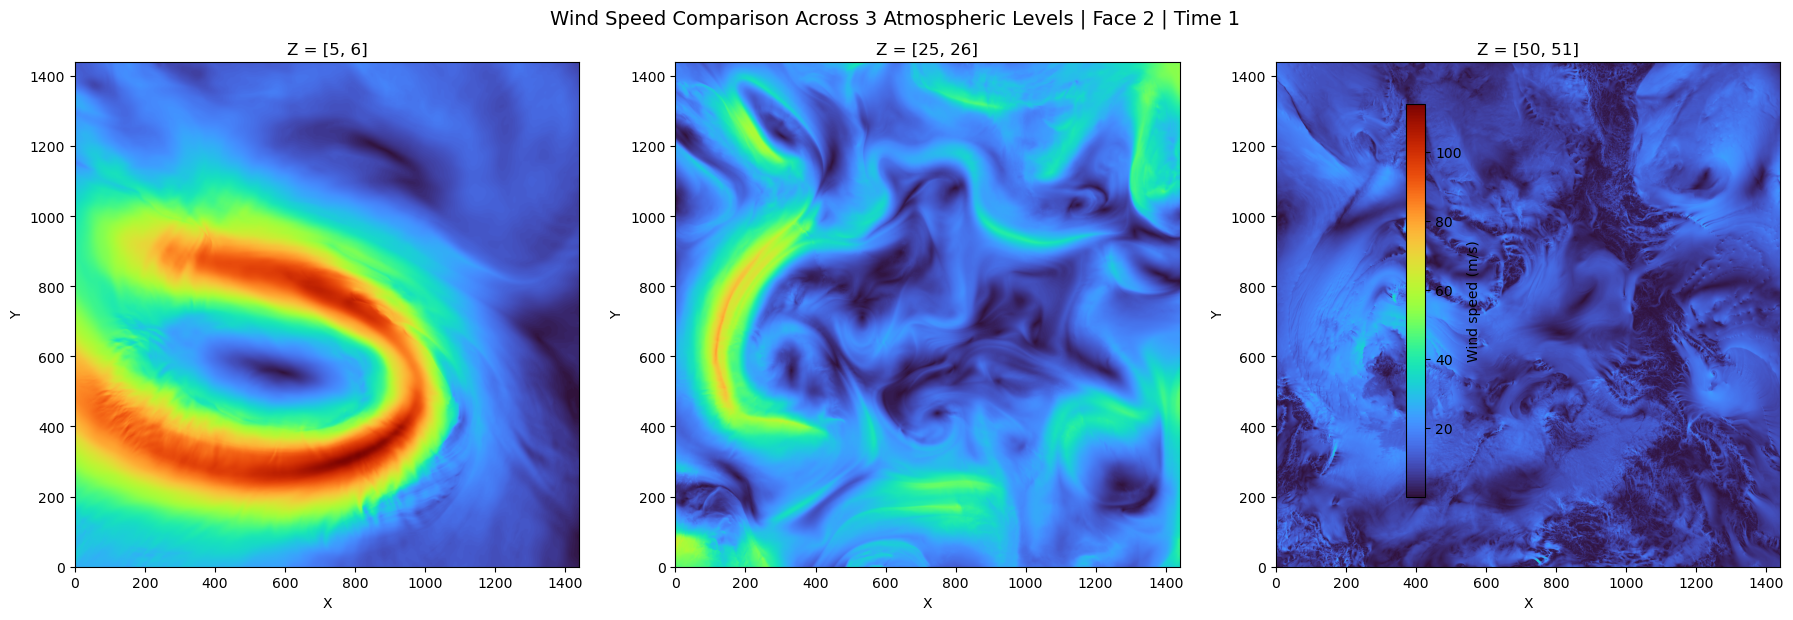

In [20]:
# Plot wind speed maps side by side for the three atmospheric levels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, z_level in enumerate(levels):
    im = axes[i].imshow(speed_maps[i], origin='lower', cmap='turbo', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'Z = {z_level}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

# Add overall title and shared colorbar
fig.suptitle(f'Wind Speed Comparison Across 3 Atmospheric Levels | Face {face} | Time {time}', fontsize=14)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Wind speed (m/s)')

plt.tight_layout()
plt.show()

## Observations

### Graph 1: Z = [5, 6]
This graph shows the wind speed at a lower atmospheric level. The pattern is strong and highly organized, with a clear curved band of high wind speed visible in warm colors like yellow, orange, and red. This suggests that at this level, the wind flow is concentrated and structured, with stronger circulation compared to the other levels.

### Graph 2: Z = [25, 26]
This graph represents the middle atmospheric level. Compared to the first graph, the wind pattern here looks more irregular and swirled, with several curved flow structures spread across the region. The wind speed is still noticeable, but the pattern is less concentrated and more complex, indicating a more mixed circulation behavior at this height.

### Graph 3: Z = [50, 51]
This graph shows the wind speed at a higher atmospheric level. Most of the plot is dominated by cooler colors, which indicates generally weaker wind speed. The structure appears more diffuse and fragmented, with fewer strong bands than the lower levels. This suggests that at higher levels, the wind is less intense and less organized in this region.

### Overall Observation
Together, these three graphs show that wind intensity and structure change noticeably with atmospheric height.

## Step 7: Read Vertical Velocity (W) and Humidity (QV)

To extend the project beyond horizontal wind speed, this section reads two additional atmospheric variables:

- **W** for vertical velocity, which helps describe upward and downward air motion.
- **QV** for humidity, which represents atmospheric moisture.

Together, these variables help connect the wind analysis to precipitation-related patterns and storm development.

In [28]:
# Read W and QV data for the same three atmospheric levels
w_maps = []
qv_maps = []

for z_level in levels:
    w_data = db_w.read(time=time, z=z_level)
    qv_data = db_humidity.read(time=time, z=z_level)

    w_maps.append(w_data[0])
    qv_maps.append(qv_data[0])

print("Computed W and QV maps for all 3 atmospheric levels")

for i, z_level in enumerate(levels):
    print(f"Level {z_level}")
    print("  W shape  =", w_maps[i].shape)
    print("  QV shape =", qv_maps[i].shape)

Computed W and QV maps for all 3 atmospheric levels
Level [5, 6]
  W shape  = (1440, 1440)
  QV shape = (1440, 1440)
Level [25, 26]
  W shape  = (1440, 1440)
  QV shape = (1440, 1440)
Level [50, 51]
  W shape  = (1440, 1440)
  QV shape = (1440, 1440)


## Step 8: Define Common Color Scales for W and QV

Separate common color scales are defined for **W** and **QV** so that each variable can be compared fairly across the three atmospheric levels.

For **W**, a percentile-based symmetric scale is used because vertical velocity contains both positive and negative values.  
For **QV**, a log-scaled range is used because humidity values vary widely across levels, and log scaling makes low-moisture structure easier to see.

In [33]:
# Common color scale for W using percentile-based symmetric limits
all_w_values = np.concatenate([w.flatten() for w in w_maps])
w_limit = np.percentile(np.abs(all_w_values), 98)

# Use log scaling for QV so low-moisture structure is easier to see
epsilon = 1e-8
qv_log_maps = [np.log10(qv + epsilon) for qv in qv_maps]

all_qv_log_values = np.concatenate([qv.flatten() for qv in qv_log_maps])
qv_log_vmin = np.percentile(all_qv_log_values, 2)
qv_log_vmax = np.percentile(all_qv_log_values, 98)

print("W scale:", -w_limit, "to", w_limit)
print("Log-scaled QV:", qv_log_vmin, "to", qv_log_vmax)

W scale: -0.15401769 to 0.15401769
Log-scaled QV: -5.4826846 to -2.2291818


## Step 9: Visualize Vertical Velocity (W)

The following figure compares vertical velocity across the same three atmospheric levels.

This helps identify regions of upward and downward motion, which are important for understanding atmospheric instability, cloud formation, and storm development.

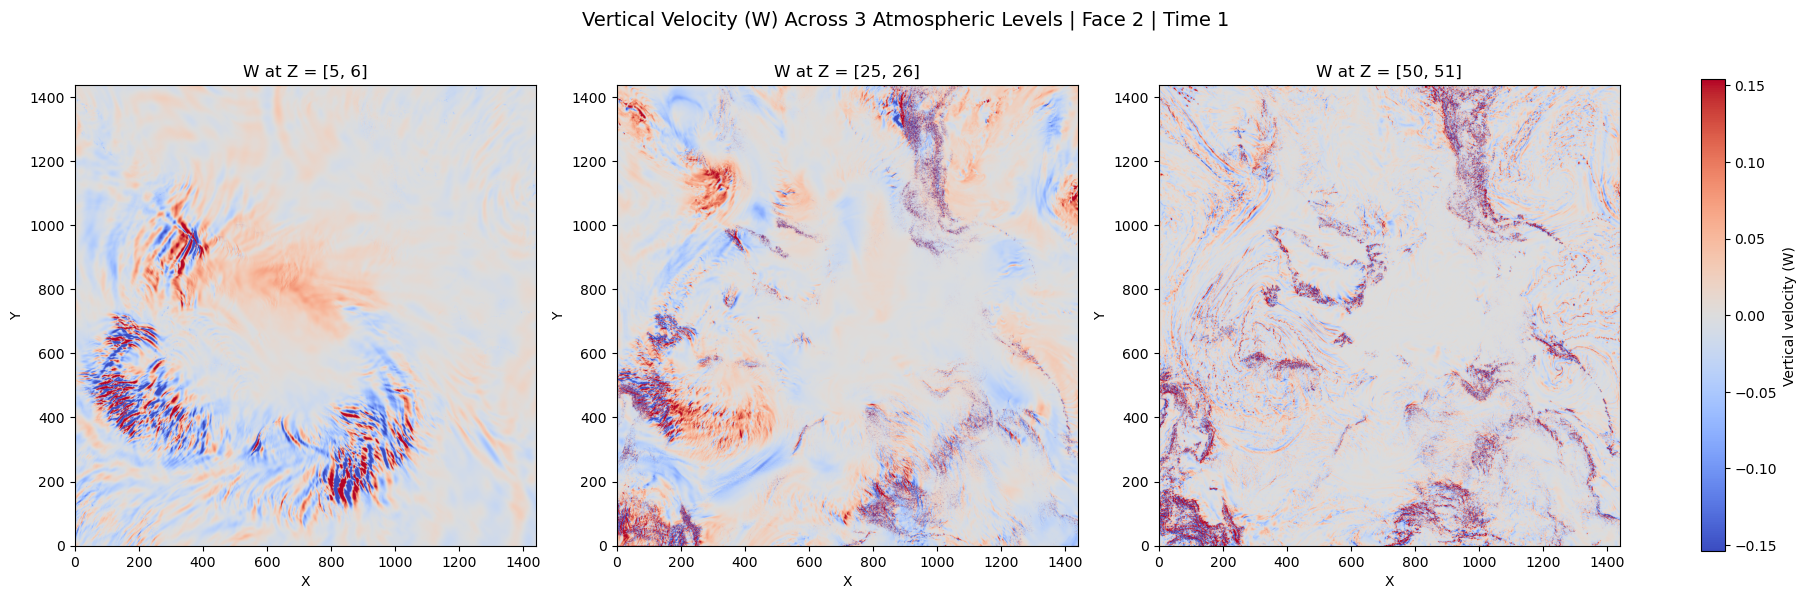

In [30]:
# Plot W maps side by side for the three atmospheric levels
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for i, z_level in enumerate(levels):
    im = axes[i].imshow(
        w_maps[i],
        origin='lower',
        cmap='coolwarm',
        vmin=-w_limit,
        vmax=w_limit
    )
    axes[i].set_title(f'W at Z = {z_level}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

fig.suptitle(f'Vertical Velocity (W) Across 3 Atmospheric Levels | Face {face} | Time {time}', fontsize=14)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Vertical velocity (W)')

plt.show()

## Step 10: Visualize Humidity (QV)

The following figure compares humidity across the same three atmospheric levels.

This helps show how atmospheric moisture changes with height, which is important for understanding moisture transport, precipitation, and storm-related processes.

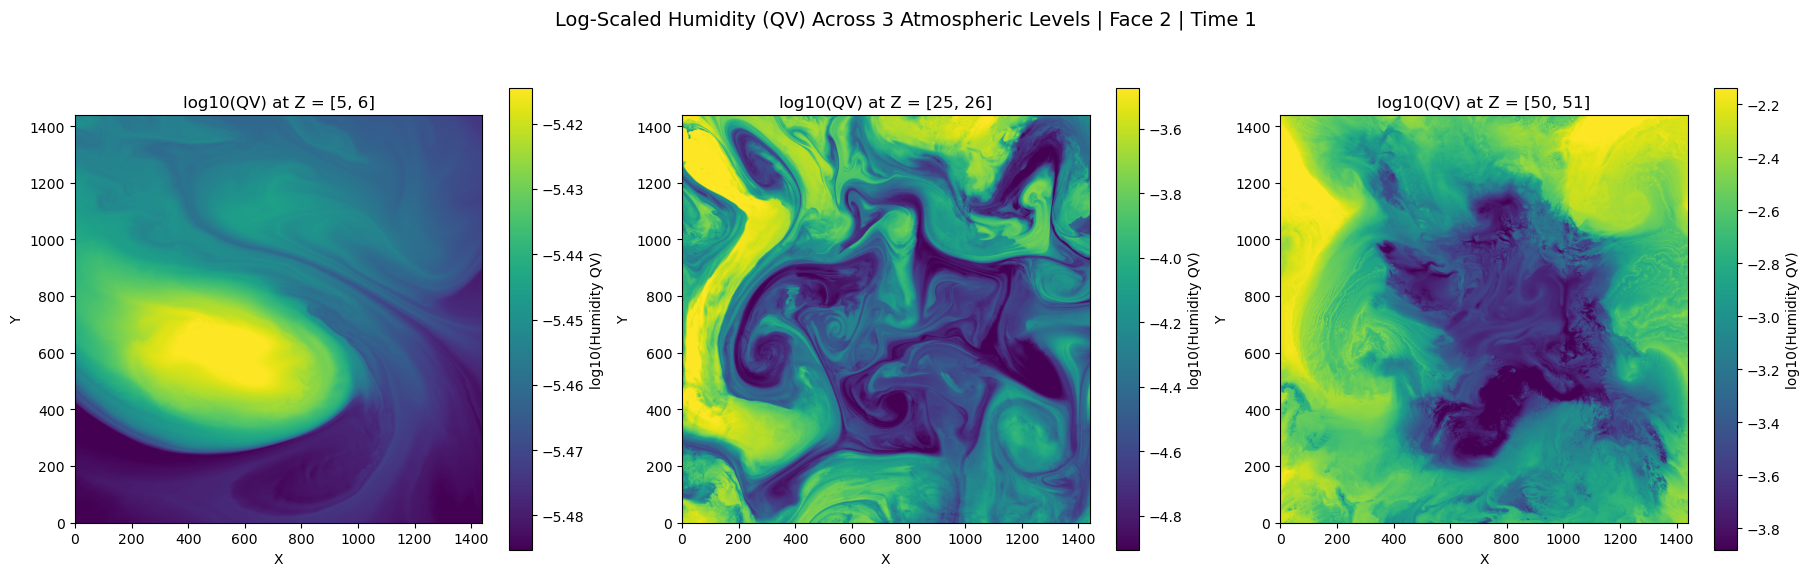

In [35]:
# Plot QV maps with separate color scaling for each atmospheric level
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for i, z_level in enumerate(levels):
    local_vmin = np.percentile(qv_log_maps[i], 2)
    local_vmax = np.percentile(qv_log_maps[i], 98)

    im = axes[i].imshow(
        qv_log_maps[i],
        origin='lower',
        cmap='viridis',
        vmin=local_vmin,
        vmax=local_vmax
    )
    axes[i].set_title(f'log10(QV) at Z = {z_level}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

    cbar = fig.colorbar(im, ax=axes[i], shrink=0.82)
    cbar.set_label('log10(Humidity QV)')

fig.suptitle(f'Log-Scaled Humidity (QV) Across 3 Atmospheric Levels | Face {face} | Time {time}', fontsize=14)
plt.show()